In [1]:
import matplotlib.pyplot as plt
import polars as pl
from matplotlib.dates import DateFormatter

from nwec.constants import PROCESSED_UTILITY_DATA, Utility


In [2]:
# Configure date range for all charts
# Set to None to include all available data
start_date = None  # e.g., pl.date(2022, 1, 1)
end_date = None  # e.g., pl.date(2025, 9, 1)

# Arrearage Counts

In [3]:
arrearage_counts = pl.read_ipc(PROCESSED_UTILITY_DATA / "arrearage_counts.arrow")

In [4]:
# Aggregate arrearage counts by utility, year, and month
# Create a date column for proper sorting and plotting
df_grouped = (
    arrearage_counts.group_by(["Utility", "Year", "Month"])
    .agg(pl.col("Arrearage Customer Count").sum())
    .with_columns(pl.date(pl.col("Year"), pl.col("Month"), 1).alias("Date"))
    .sort("Date")
)

# Apply date range filter if specified
if start_date is not None:
    df_grouped = df_grouped.filter(pl.col("Date") >= start_date)
if end_date is not None:
    df_grouped = df_grouped.filter(pl.col("Date") <= end_date)

# Pivot to get utilities as columns and fill nulls with 0 for proper stacking
df_pivot = df_grouped.pivot(values="Arrearage Customer Count", index="Date", on="Utility").sort("Date").fill_null(0)

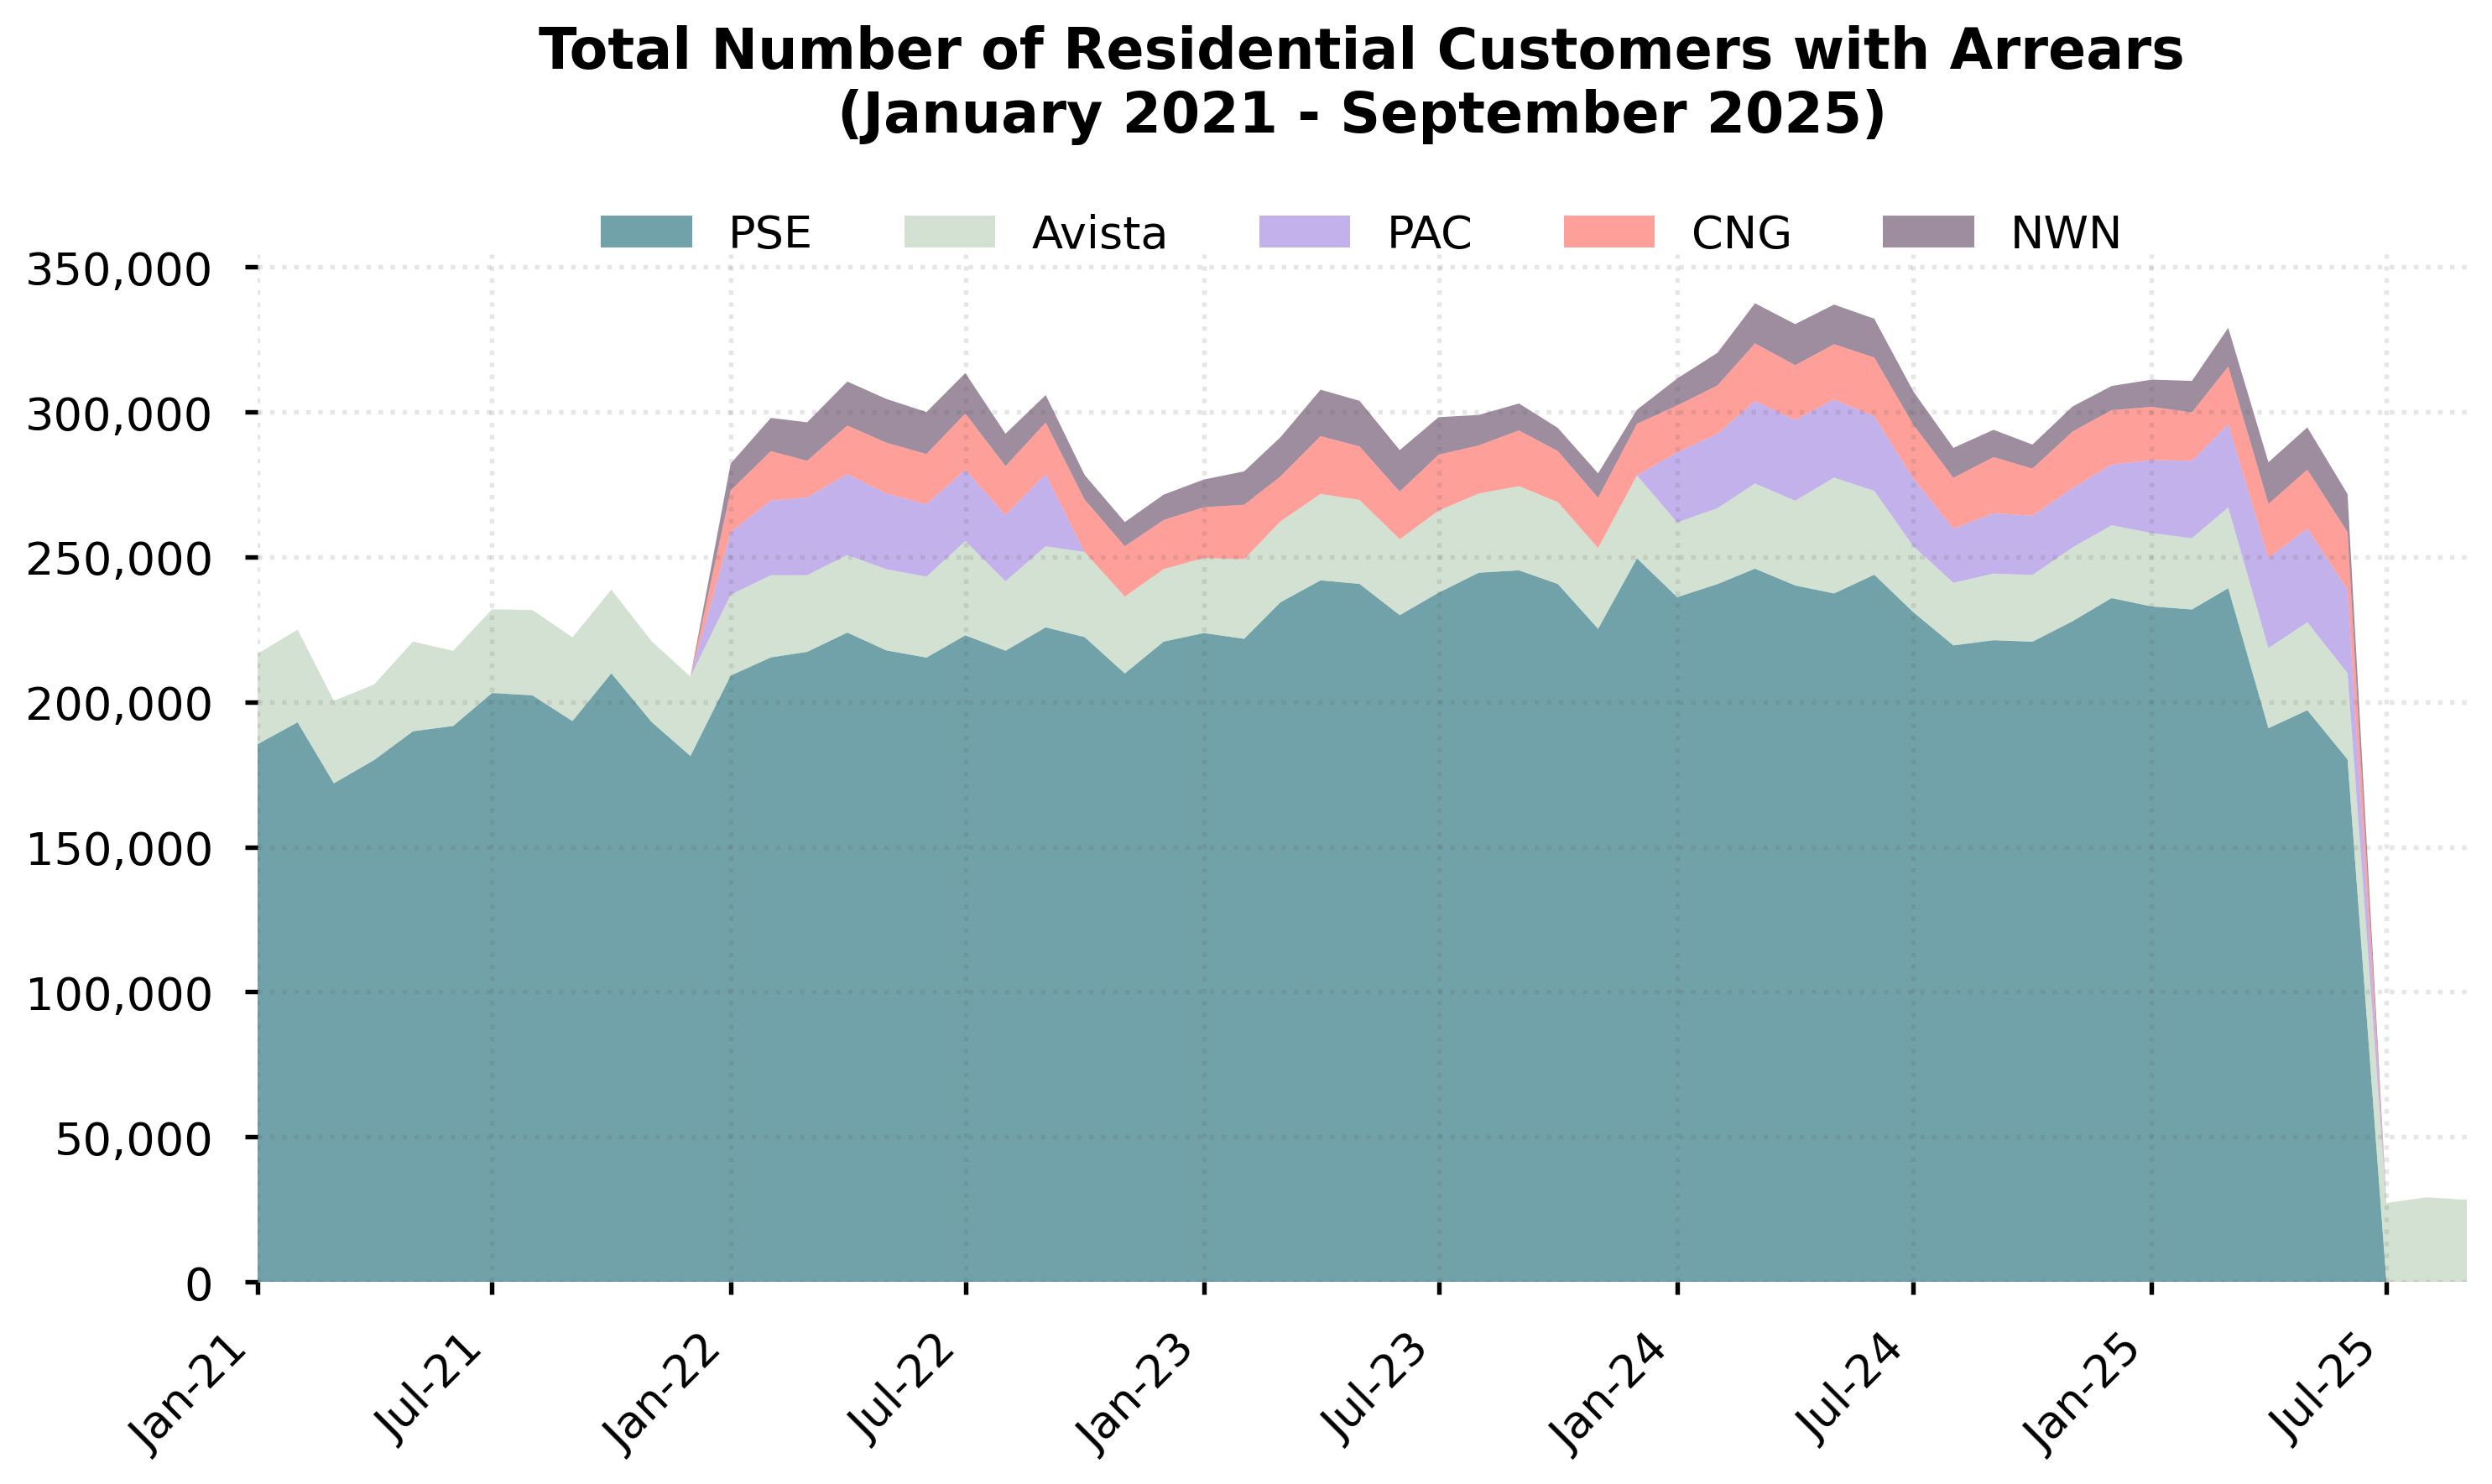

In [5]:
# Create stacked area chart for arrearage counts by utility
with plt.style.context("seaborn-v0_8-talk"):
    df_pandas = df_pivot.to_pandas()
    dates = df_pandas["Date"]

    # Get first and last month for title
    first_month = dates.min().strftime("%B %Y")
    last_month = dates.max().strftime("%B %Y")

    colors = ["#156570", "#B4CEB3", "#9B7EDE", "#FE5F55", "#5C415D"]

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    # Set up grid
    ax.grid(which="major", axis="x", linestyle=":", color="#5b5b5b", alpha=0.15, zorder=1)
    ax.grid(which="major", axis="y", linestyle=":", color="#5b5b5b", alpha=0.15, zorder=1)

    # Get utility columns (all except Date)
    utilities = [Utility[util.name].code for util in Utility]
    # Prepare data for stackplot
    utility_data = [df_pandas[util].values for util in utilities]

    # Create stacked area chart
    ax.stackplot(dates, *utility_data, labels=utilities, alpha=0.6, colors=colors[: len(utilities)])

    # Formatting
    ax.set_title(
        f"Total Number of Residential Customers with Arrears\n({first_month} - {last_month})",
        fontsize=16,
        fontweight="bold",
        pad=35,
    )
    ax.set_xlabel("")  # Remove x-axis label
    ax.set_ylabel("")

    # Format x-axis dates as "Jan-25"
    ax.xaxis.set_major_formatter(DateFormatter("%b-%y"))
    plt.xticks(rotation=45, ha="right")  # Rotate labels

    # Format y-axis with thousands separator
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

    # Remove all spines except left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Remove padding on x-axis to eliminate space on left
    ax.margins(x=0)

    # Move legend to horizontal at top, below title with more spacing
    ax.legend(loc="upper center", frameon=False, ncol=len(utilities), bbox_to_anchor=(0.5, 1.08))

    plt.tight_layout()
    plt.savefig("graphs/arrearage_counts_stacked.png", dpi=300, bbox_inches="tight")
    plt.show()

# Arrearage Amounts

In [6]:
arrearage_amounts = pl.read_ipc(PROCESSED_UTILITY_DATA / "arrearage_amounts.arrow")

In [7]:
# Aggregate arrearage amounts by utility, year, and month
# Create a date column for proper sorting and plotting
df_amounts_grouped = (
    arrearage_amounts.group_by(["Utility", "Year", "Month"])
    .agg(pl.col("Arrearage_Amount").sum())
    .with_columns(pl.date(pl.col("Year"), pl.col("Month"), 1).alias("Date"))
    .sort("Date")
)

# Apply date range filter if specified
if start_date is not None:
    df_amounts_grouped = df_amounts_grouped.filter(pl.col("Date") >= start_date)
if end_date is not None:
    df_amounts_grouped = df_amounts_grouped.filter(pl.col("Date") <= end_date)

# Pivot to get utilities as columns and fill nulls with 0 for proper stacking
df_amounts_pivot = (
    df_amounts_grouped.pivot(values="Arrearage_Amount", index="Date", on="Utility").sort("Date").fill_null(0)
)

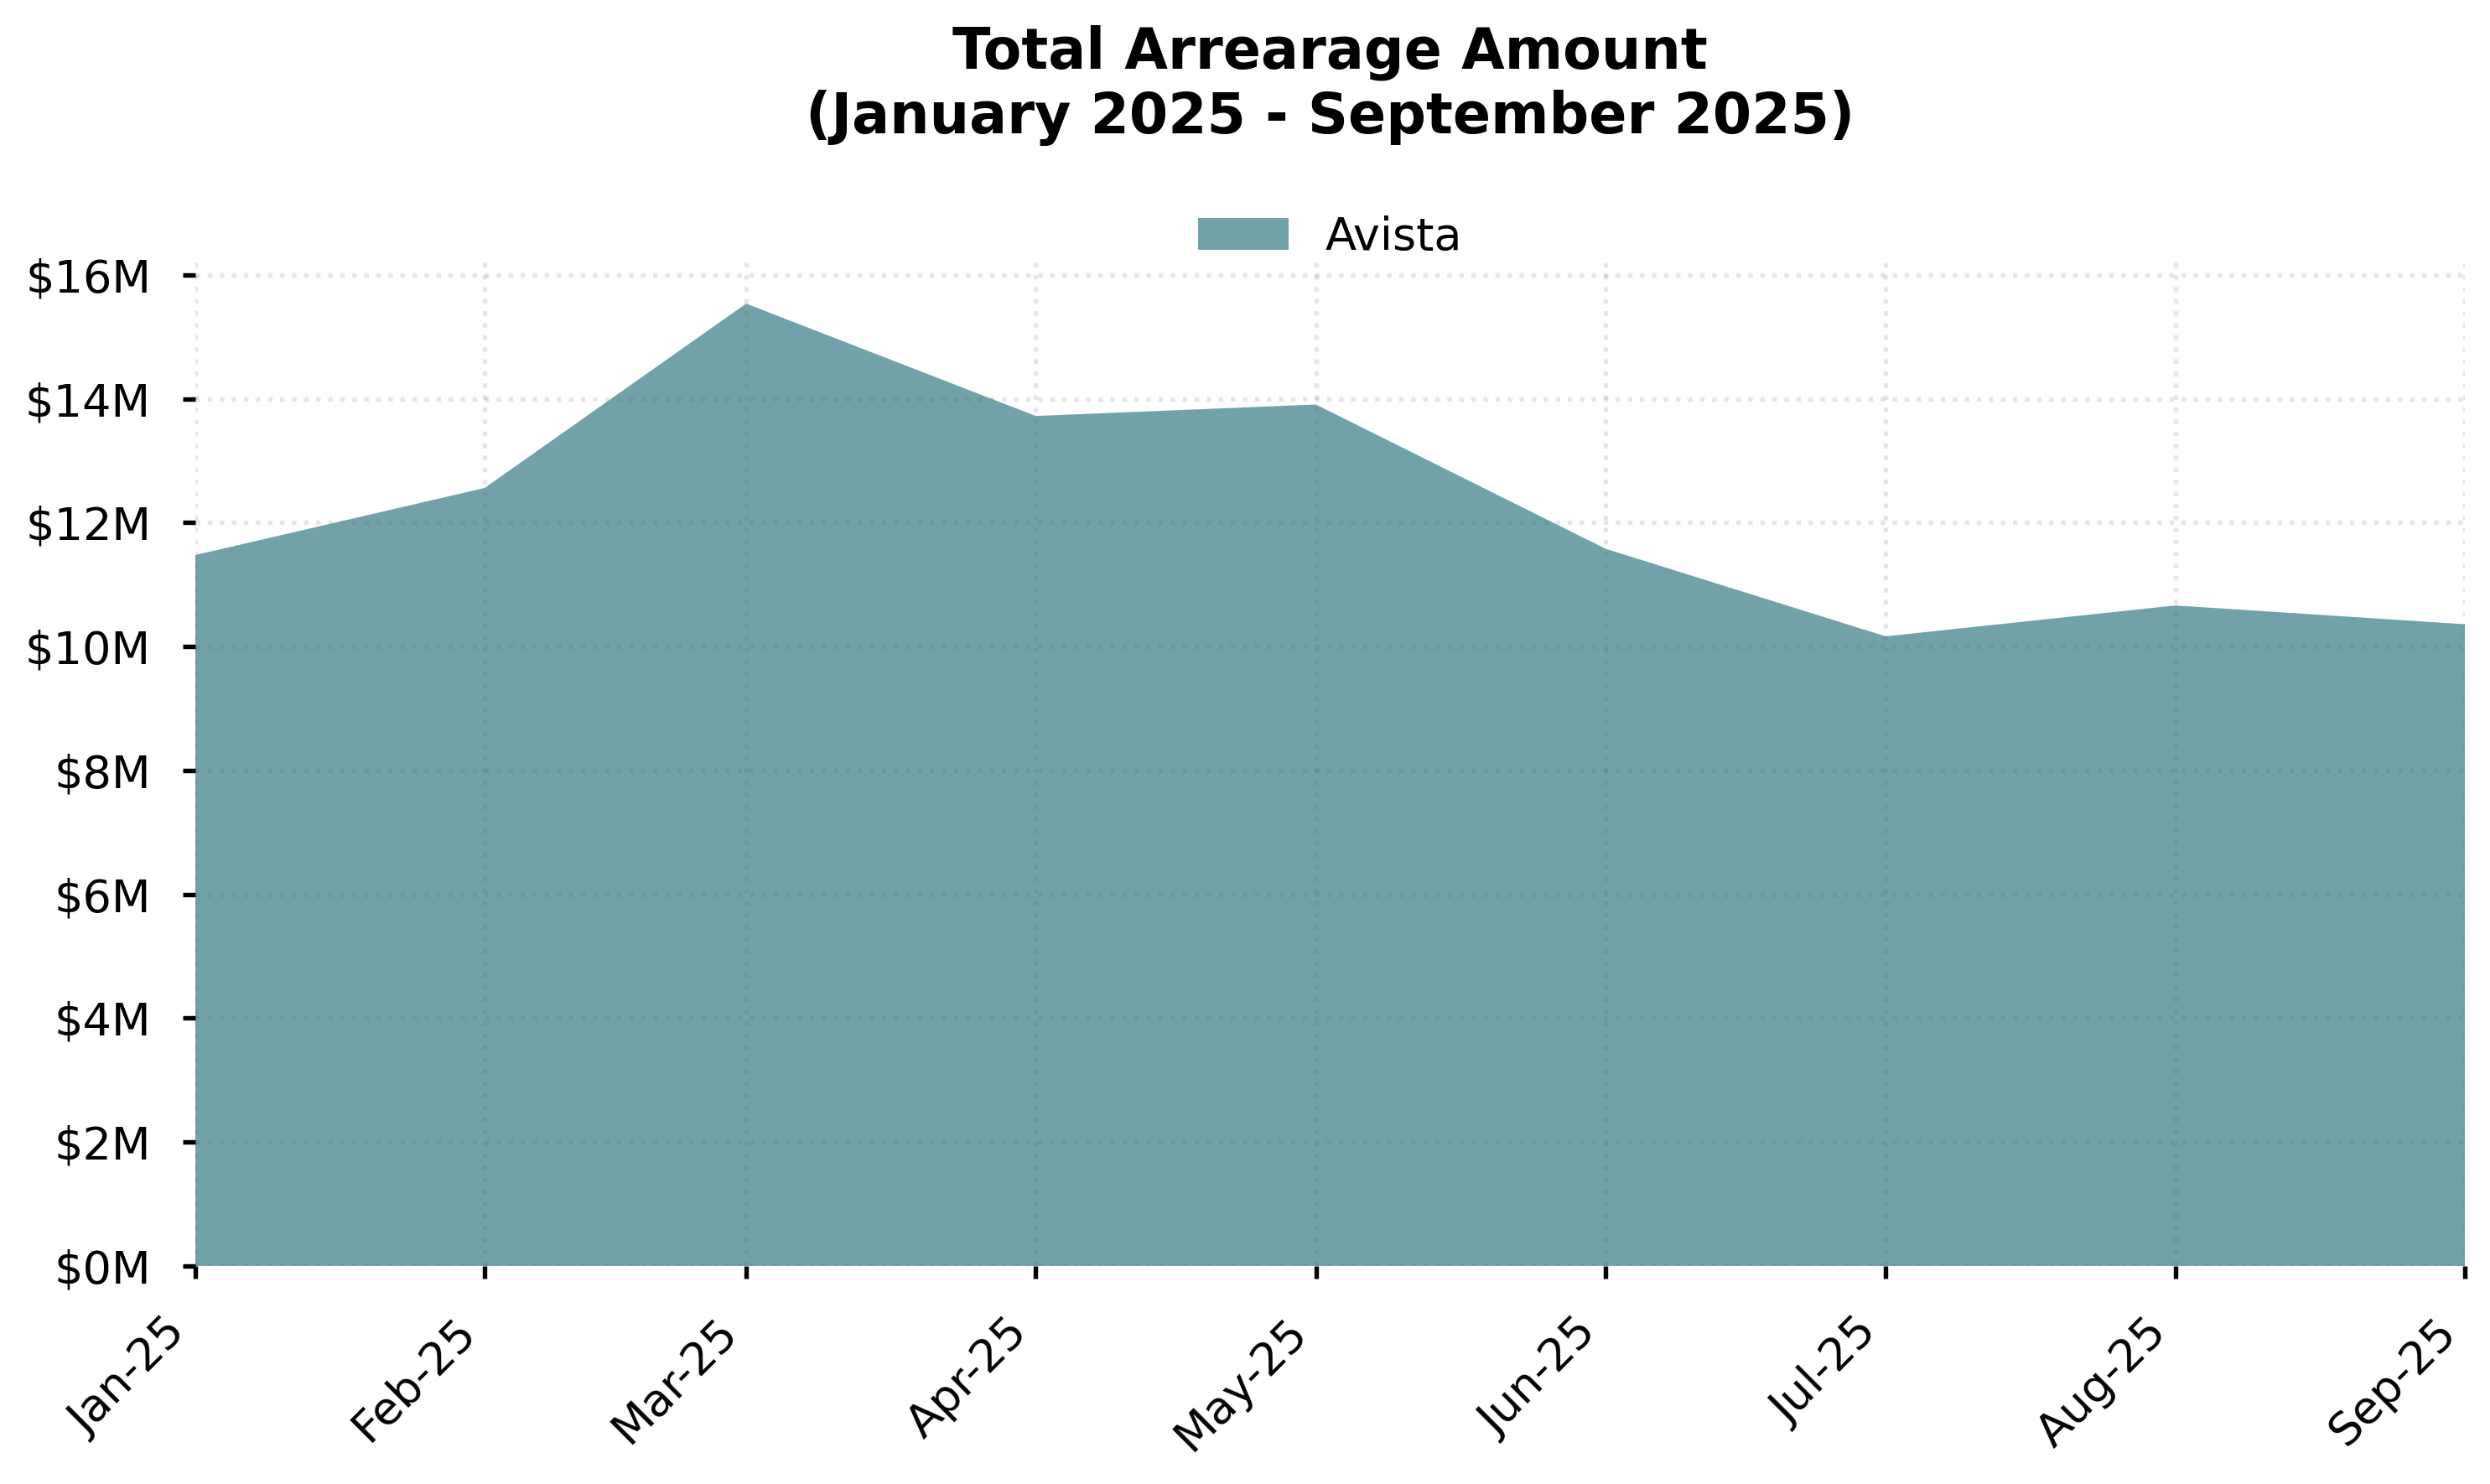

In [8]:
# Create stacked area chart for arrearage amounts by utility
with plt.style.context("seaborn-v0_8-talk"):
    df_pandas_amounts = df_amounts_pivot.to_pandas()
    dates_amounts = df_pandas_amounts["Date"]

    # Get first and last month for title
    first_month_amounts = dates_amounts.min().strftime("%B %Y")
    last_month_amounts = dates_amounts.max().strftime("%B %Y")

    colors = ["#156570", "#B4CEB3", "#9B7EDE", "#FE5F55", "#5C415D"]

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    # Set up grid
    ax.grid(which="major", axis="x", linestyle=":", color="#5b5b5b", alpha=0.15, zorder=1)
    ax.grid(which="major", axis="y", linestyle=":", color="#5b5b5b", alpha=0.15, zorder=1)

    # Get utility columns in Utility enum order, but only include those present in the data
    all_utilities = [Utility[util.name].code for util in Utility]
    available_utilities = [util for util in all_utilities if util in df_pandas_amounts.columns]
    # Prepare data for stackplot
    utility_data_amounts = [df_pandas_amounts[util].values for util in available_utilities]

    # Create stacked area chart
    ax.stackplot(
        dates_amounts,
        *utility_data_amounts,
        labels=available_utilities,
        alpha=0.6,
        colors=colors[: len(available_utilities)],
    )

    # Formatting
    ax.set_title(
        f"Total Arrearage Amount\n({first_month_amounts} - {last_month_amounts})",
        fontsize=16,
        fontweight="bold",
        pad=35,
    )
    ax.set_xlabel("")  # Remove x-axis label
    ax.set_ylabel("")

    # Format x-axis dates as "Jan-25"
    ax.xaxis.set_major_formatter(DateFormatter("%b-%y"))
    plt.xticks(rotation=45, ha="right")  # Rotate labels

    # Format y-axis with dollar sign and millions
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x / 1e6:.0f}M"))

    # Remove all spines except left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Remove padding on x-axis to eliminate space on left
    ax.margins(x=0)

    # Move legend to horizontal at top, below title with more spacing
    ax.legend(loc="upper center", frameon=False, ncol=len(available_utilities), bbox_to_anchor=(0.5, 1.08))

    plt.tight_layout()
    plt.savefig("graphs/arrearage_amounts_stacked.png", dpi=300, bbox_inches="tight")
    plt.show()

## Arrearage Amounts - Vintages

In [9]:
# Aggregate arrearage amounts by vintage and month (excluding Total Arrearages)
df_vintage = (
    arrearage_amounts.filter(pl.col("Vintage") != "Total Arrearages")
    .group_by(["Year", "Month", "Vintage"])
    .agg(pl.col("Arrearage_Amount").sum())
    .with_columns(pl.date(pl.col("Year"), pl.col("Month"), 1).alias("Date"))
    .sort("Date")
)

# Apply date range filter if specified
if start_date is not None:
    df_vintage = df_vintage.filter(pl.col("Date") >= start_date)
if end_date is not None:
    df_vintage = df_vintage.filter(pl.col("Date") <= end_date)

# Pivot to get vintages as columns
df_vintage_pivot = df_vintage.pivot(values="Arrearage_Amount", index="Date", on="Vintage").sort("Date")

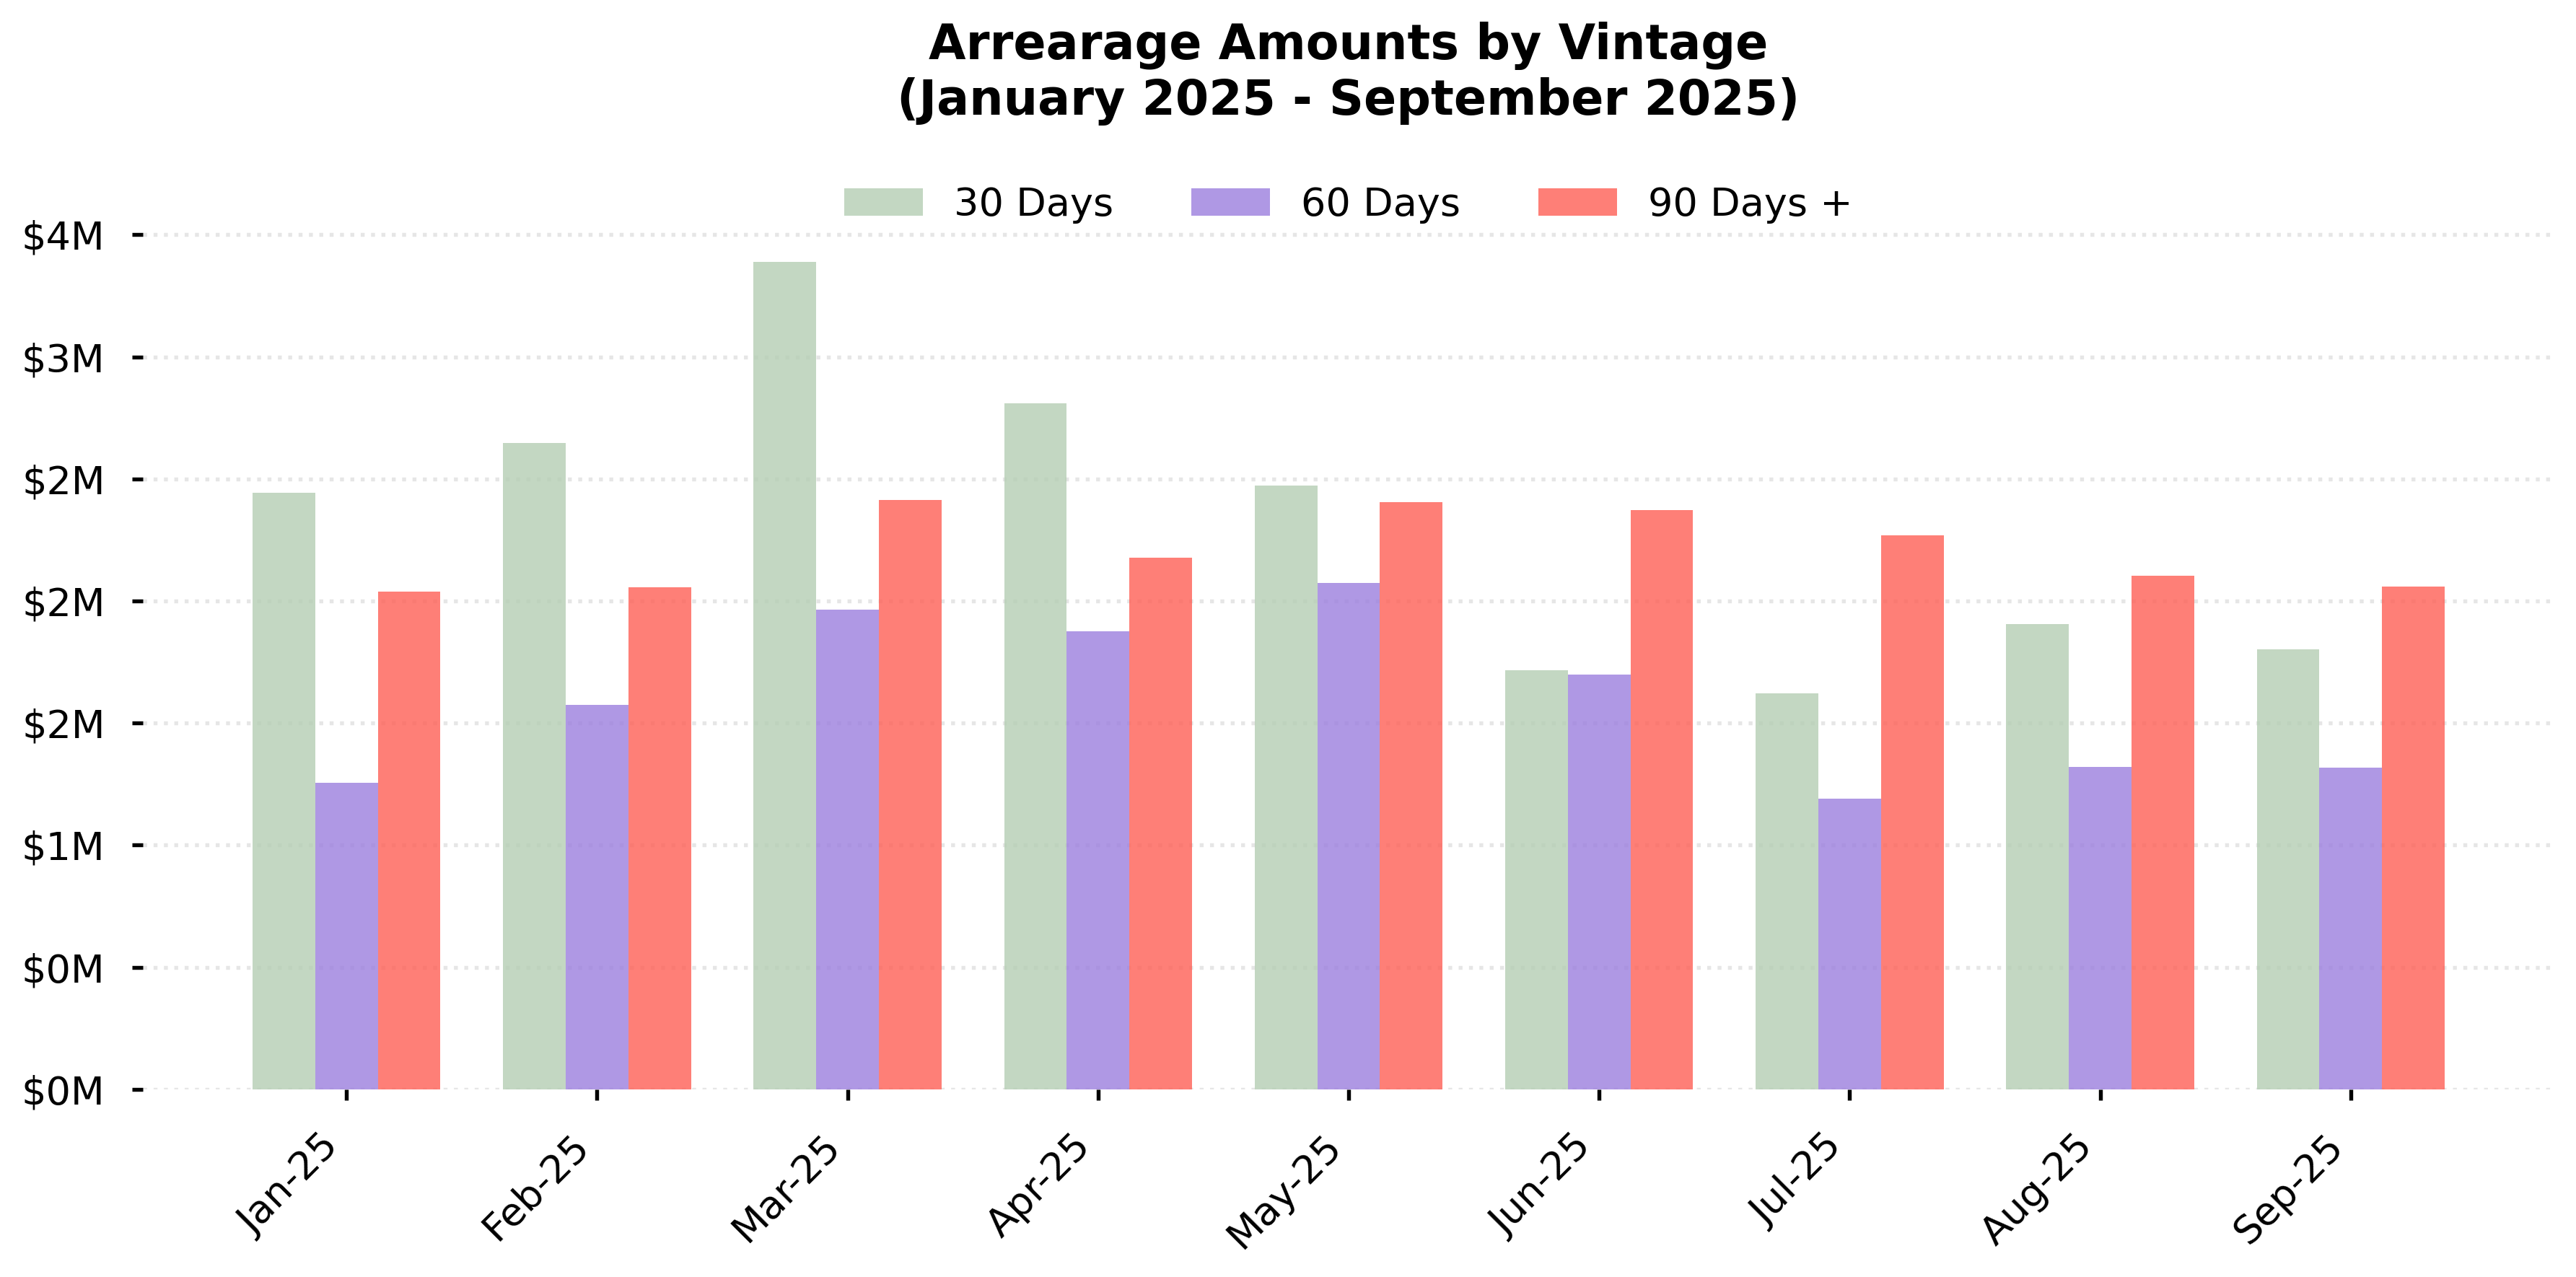

In [10]:
# Create clustered bar chart for arrearage amounts by vintage
with plt.style.context("seaborn-v0_8-talk"):
    df_pandas_vintage = df_vintage_pivot.to_pandas()
    dates_vintage = df_pandas_vintage["Date"]

    # Get first and last month for title
    first_month_vintage = dates_vintage.min().strftime("%B %Y")
    last_month_vintage = dates_vintage.max().strftime("%B %Y")

    # Define vintage order and colors
    vintage_order = ["30 Days", "60 Days", "90 Days +"]
    vintage_colors = ["#B4CEB3", "#9B7EDE", "#FE5F55"]

    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

    # Set up grid
    ax.grid(which="major", axis="y", linestyle=":", color="#5b5b5b", alpha=0.15, zorder=1)

    # Set up bar positions
    x = range(len(dates_vintage))
    width = 0.25  # Width of each bar
    multiplier = 0

    # Create clustered bars
    for vintage in vintage_order:
        if vintage in df_pandas_vintage.columns:
            offset = width * multiplier
            bars = ax.bar(
                [pos + offset for pos in x],
                df_pandas_vintage[vintage].values,
                width,
                label=vintage,
                color=vintage_colors[multiplier],
                alpha=0.8,
                zorder=3,
            )
            multiplier += 1

    # Formatting
    ax.set_title(
        f"Arrearage Amounts by Vintage\n({first_month_vintage} - {last_month_vintage})",
        fontsize=16,
        fontweight="bold",
        pad=35,
    )
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Format x-axis with month labels
    ax.set_xticks([pos + width for pos in x])
    ax.set_xticklabels([date.strftime("%b-%y") for date in dates_vintage], rotation=45, ha="right")

    # Format y-axis with dollar sign and millions
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x / 1e6:.0f}M"))

    # Remove all spines except left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Move legend to horizontal at top
    ax.legend(loc="upper center", frameon=False, ncol=len(vintage_order), bbox_to_anchor=(0.5, 1.08))

    plt.tight_layout()
    plt.savefig("graphs/arrearage_amounts_vintage.png", dpi=300, bbox_inches="tight")
    plt.show()

## Arrearage Amounts - KLI Vintages

In [11]:
kli_arrearage_amounts = pl.read_ipc(PROCESSED_UTILITY_DATA / "kli_arrearage_amounts.arrow")

In [12]:
# Aggregate KLI arrearage amounts by vintage and month (excluding Total Arrearages)
df_kli_vintage = (
    kli_arrearage_amounts.filter(pl.col("Vintage") != "Total Arrearages")
    .group_by(["Year", "Month", "Vintage"])
    .agg(pl.col("Arrearage_Amount").sum())
    .with_columns(pl.date(pl.col("Year"), pl.col("Month"), 1).alias("Date"))
    .sort("Date")
)

# Apply date range filter if specified
if start_date is not None:
    df_kli_vintage = df_kli_vintage.filter(pl.col("Date") >= start_date)
if end_date is not None:
    df_kli_vintage = df_kli_vintage.filter(pl.col("Date") <= end_date)

# Pivot to get vintages as columns
df_kli_vintage_pivot = df_kli_vintage.pivot(values="Arrearage_Amount", index="Date", on="Vintage").sort("Date")

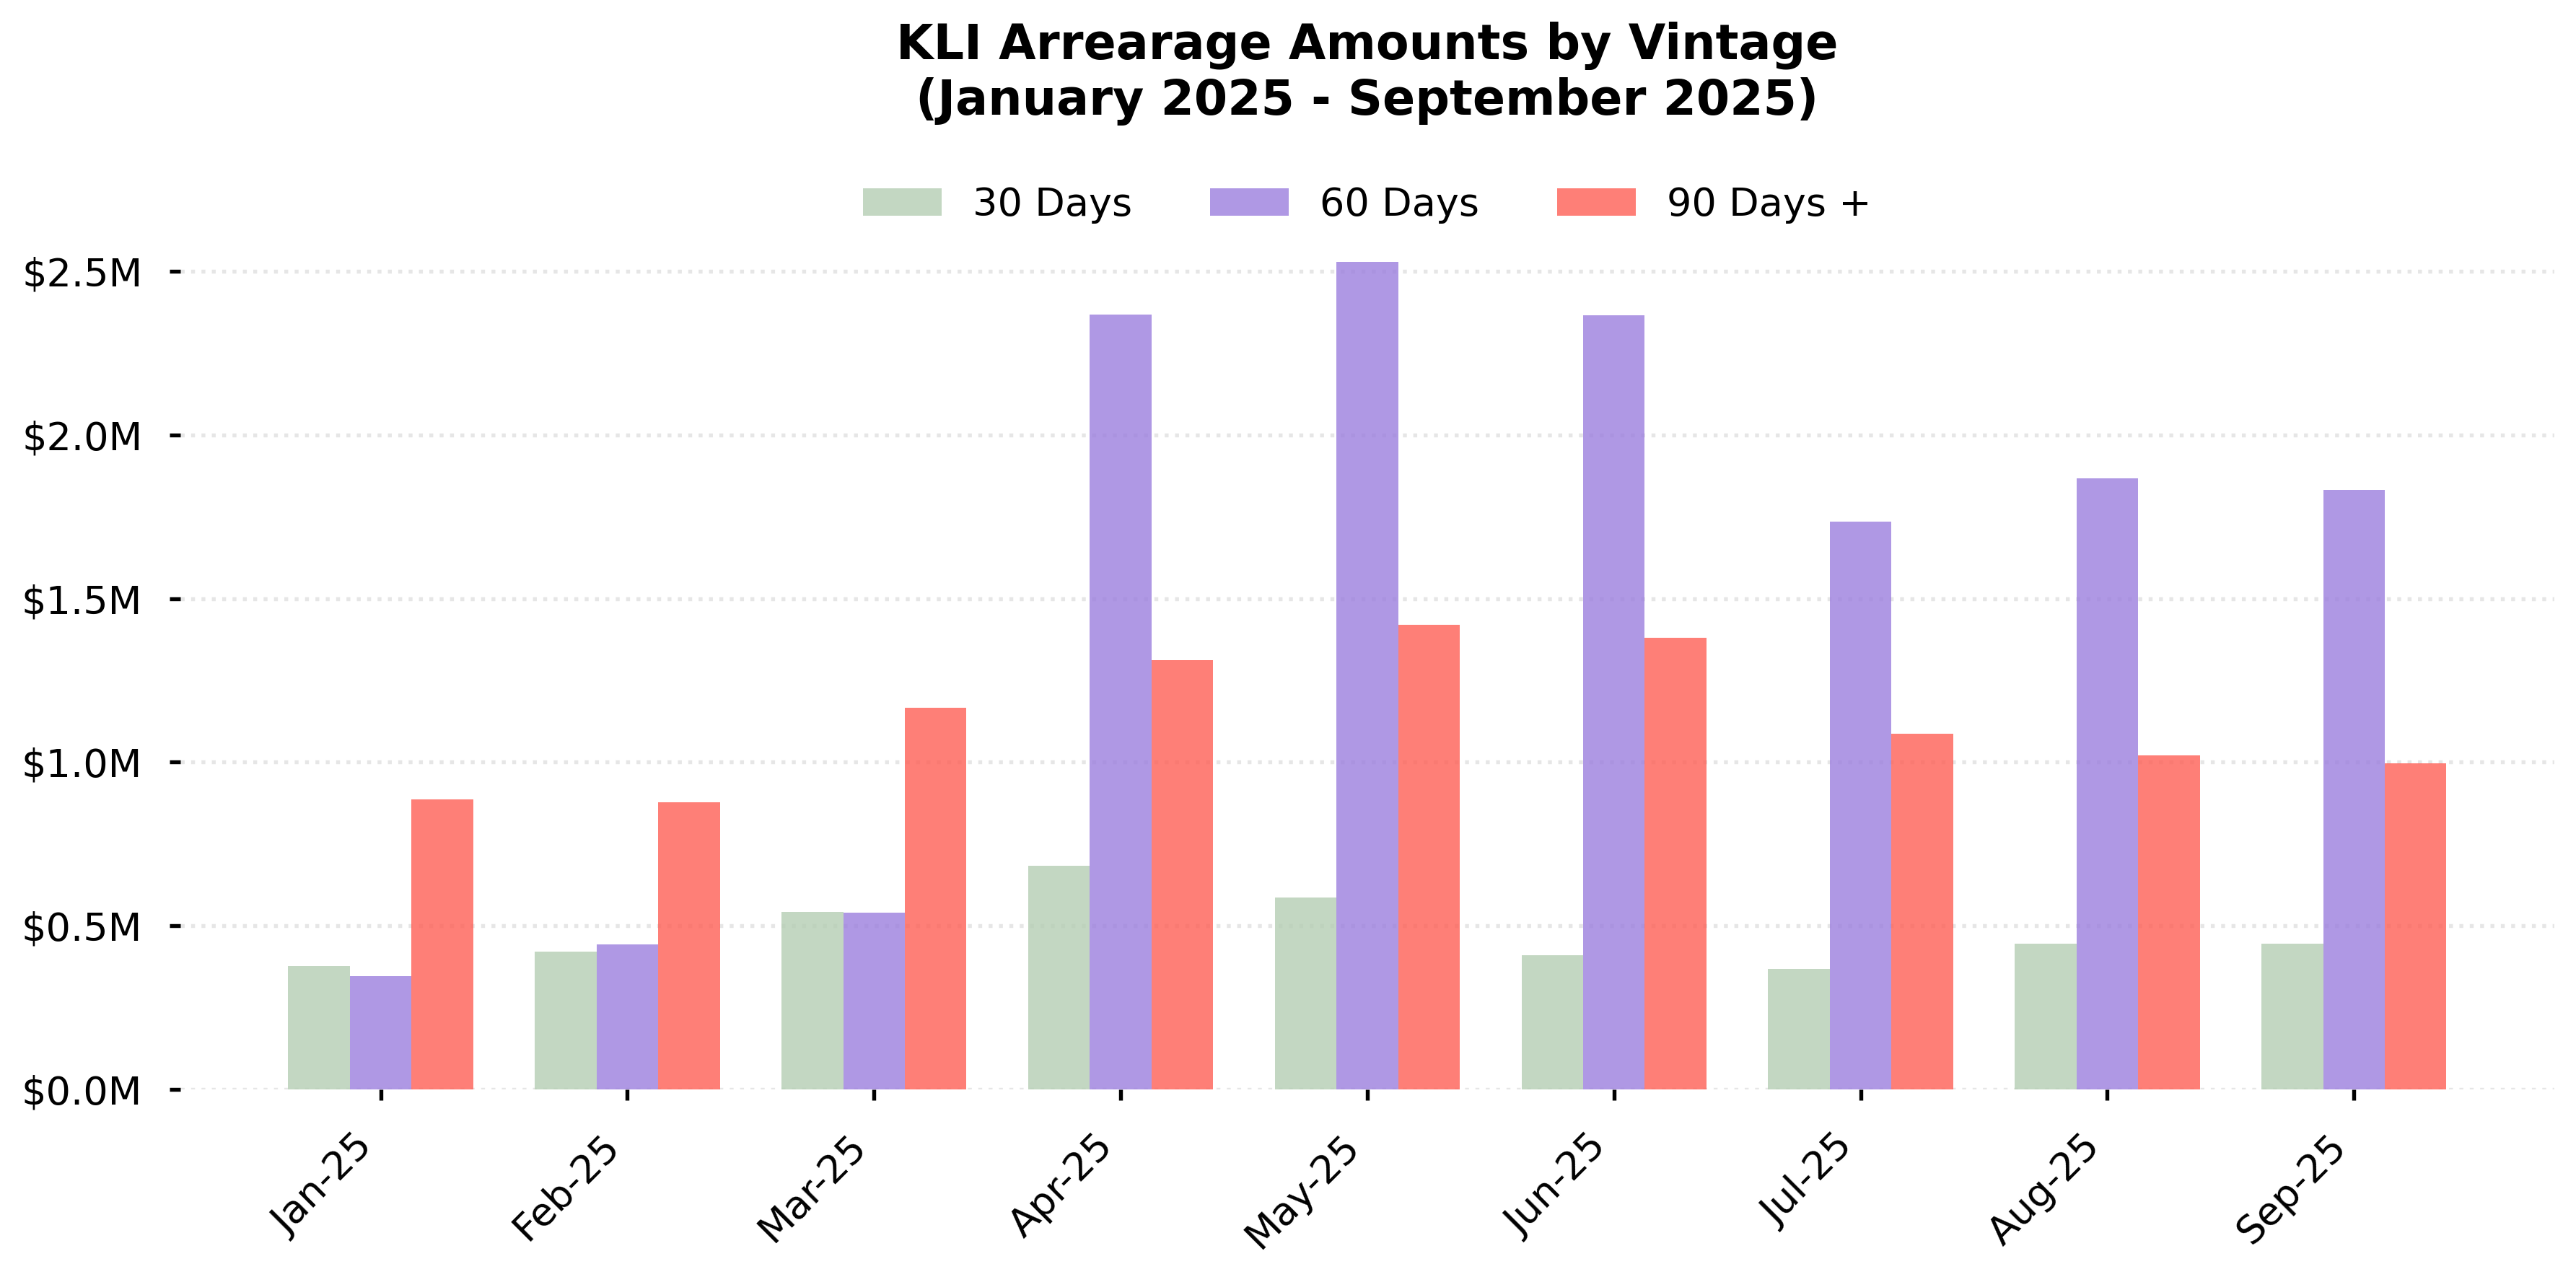

In [13]:
# Create clustered bar chart for KLI arrearage amounts by vintage
with plt.style.context("seaborn-v0_8-talk"):
    df_pandas_kli_vintage = df_kli_vintage_pivot.to_pandas()
    dates_kli_vintage = df_pandas_kli_vintage["Date"]

    # Get first and last month for title
    first_month_kli_vintage = dates_kli_vintage.min().strftime("%B %Y")
    last_month_kli_vintage = dates_kli_vintage.max().strftime("%B %Y")

    # Define vintage order and colors
    vintage_order = ["30 Days", "60 Days", "90 Days +"]
    vintage_colors = ["#B4CEB3", "#9B7EDE", "#FE5F55"]

    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

    # Set up grid
    ax.grid(which="major", axis="y", linestyle=":", color="#5b5b5b", alpha=0.15, zorder=1)

    # Set up bar positions
    x = range(len(dates_kli_vintage))
    width = 0.25  # Width of each bar
    multiplier = 0

    # Create clustered bars
    for vintage in vintage_order:
        if vintage in df_pandas_kli_vintage.columns:
            offset = width * multiplier
            bars = ax.bar(
                [pos + offset for pos in x],
                df_pandas_kli_vintage[vintage].values,
                width,
                label=vintage,
                color=vintage_colors[multiplier],
                alpha=0.8,
                zorder=3,
            )
            multiplier += 1

    # Formatting
    ax.set_title(
        f"KLI Arrearage Amounts by Vintage\n({first_month_kli_vintage} - {last_month_kli_vintage})",
        fontsize=16,
        fontweight="bold",
        pad=35,
    )
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Format x-axis with month labels
    ax.set_xticks([pos + width for pos in x])
    ax.set_xticklabels([date.strftime("%b-%y") for date in dates_kli_vintage], rotation=45, ha="right")

    # Format y-axis with dollar sign and millions
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x / 1e6:.1f}M"))

    # Remove all spines except left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Move legend to horizontal at top
    ax.legend(loc="upper center", frameon=False, ncol=len(vintage_order), bbox_to_anchor=(0.5, 1.08))

    plt.tight_layout()
    plt.savefig("graphs/kli_arrearage_amounts_vintage.png", dpi=300, bbox_inches="tight")
    plt.show()

# Bill Assistance

In [14]:
bill_assist = pl.read_ipc(PROCESSED_UTILITY_DATA / "bill_assist.arrow")

In [15]:
# Aggregate Bill Assistance by Utility and Date
df_bill_assist_agg = (
    bill_assist.group_by(["Utility", "Year", "Month"])
    .agg(pl.col("Bill Assist Customer Count").sum())
    .with_columns(pl.date("Year", "Month", 1).alias("Date"))
)

# Apply date range filter if configured
if start_date is not None:
    df_bill_assist_agg = df_bill_assist_agg.filter(pl.col("Date") >= start_date)
if end_date is not None:
    df_bill_assist_agg = df_bill_assist_agg.filter(pl.col("Date") <= end_date)

# Pivot to get utilities as columns
df_bill_assist_pivot = (
    df_bill_assist_agg.pivot(values="Bill Assist Customer Count", index="Date", on="Utility").fill_null(0).sort("Date")
)

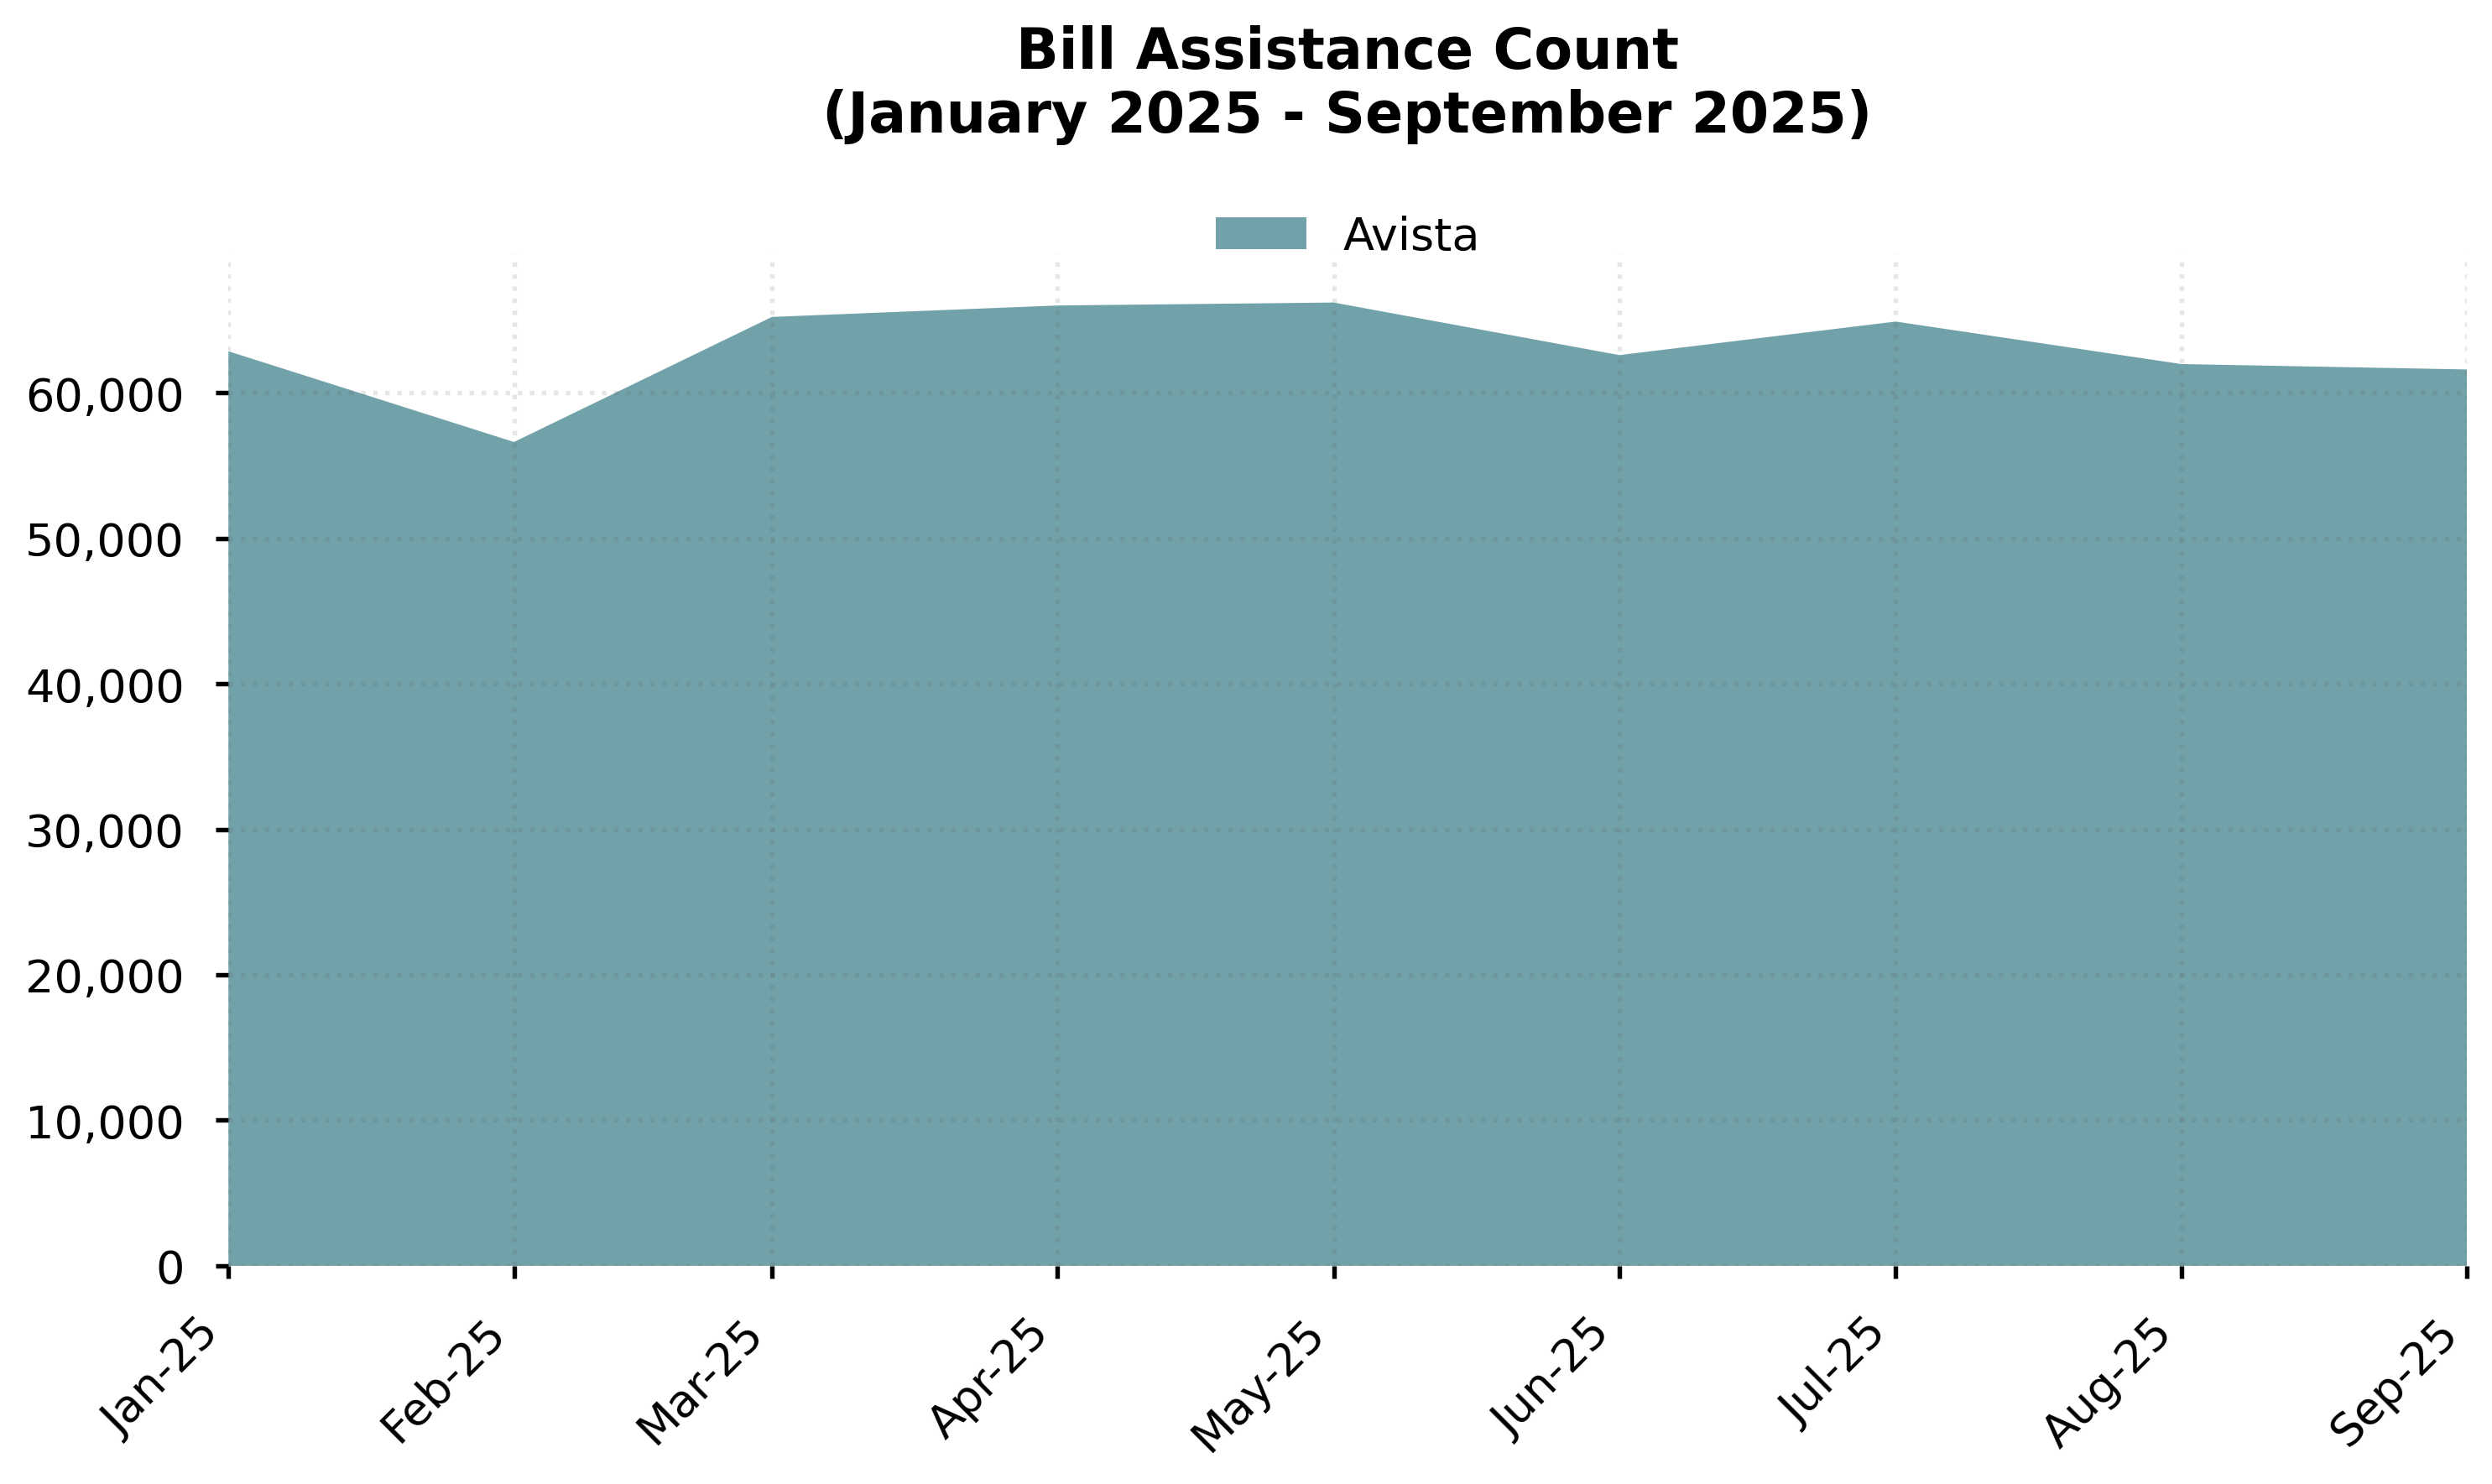

In [16]:
# Create stacked area chart for bill assistance by utility
with plt.style.context("seaborn-v0_8-talk"):
    df_pandas_bill_assist = df_bill_assist_pivot.to_pandas()
    dates_bill_assist = df_pandas_bill_assist["Date"]

    # Get first and last month for title
    first_month_bill_assist = dates_bill_assist.min().strftime("%B %Y")
    last_month_bill_assist = dates_bill_assist.max().strftime("%B %Y")

    colors = ["#156570", "#B4CEB3", "#9B7EDE", "#FE5F55", "#5C415D"]

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    # Set up grid
    ax.grid(which="major", axis="x", linestyle=":", color="#5b5b5b", alpha=0.15, zorder=1)
    ax.grid(which="major", axis="y", linestyle=":", color="#5b5b5b", alpha=0.15, zorder=1)

    # Get utility columns in Utility enum order, but only include those present in the data
    all_utilities = [Utility[util.name].code for util in Utility]
    available_utilities = [util for util in all_utilities if util in df_pandas_bill_assist.columns]
    # Prepare data for stackplot
    utility_data_bill_assist = [df_pandas_bill_assist[util].values for util in available_utilities]

    # Create stacked area chart
    ax.stackplot(
        dates_bill_assist,
        *utility_data_bill_assist,
        labels=available_utilities,
        alpha=0.6,
        colors=colors[: len(available_utilities)],
    )

    # Formatting
    ax.set_title(
        f"Bill Assistance Count\n({first_month_bill_assist} - {last_month_bill_assist})",
        fontsize=16,
        fontweight="bold",
        pad=35,
    )
    ax.set_xlabel("")  # Remove x-axis label
    ax.set_ylabel("")

    # Format x-axis dates as "Jan-25"
    ax.xaxis.set_major_formatter(DateFormatter("%b-%y"))
    plt.xticks(rotation=45, ha="right")  # Rotate labels

    # Format y-axis with thousands separator
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

    # Remove all spines except left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Remove padding on x-axis to eliminate space on left
    ax.margins(x=0)

    # Move legend to horizontal at top, below title with more spacing
    ax.legend(loc="upper center", frameon=False, ncol=len(available_utilities), bbox_to_anchor=(0.5, 1.08))

    plt.tight_layout()
    plt.savefig("graphs/bill_assist_stacked.png", dpi=300, bbox_inches="tight")
    plt.show()

# Disconnections

In [17]:
disconnections = pl.read_ipc(PROCESSED_UTILITY_DATA / "disconnections.arrow")

In [18]:
# Aggregate Disconnections by Utility and Date
df_disconnections_agg = (
    disconnections.group_by(["Utility", "Year", "Month"])
    .agg(pl.col("Number of Disconnects").sum())
    .with_columns(pl.date("Year", "Month", 1).alias("Date"))
)

# Apply date range filter if configured
if start_date is not None:
    df_disconnections_agg = df_disconnections_agg.filter(pl.col("Date") >= start_date)
if end_date is not None:
    df_disconnections_agg = df_disconnections_agg.filter(pl.col("Date") <= end_date)

# Pivot to get utilities as columns
df_disconnections_pivot = (
    df_disconnections_agg.pivot(values="Number of Disconnects", index="Date", on="Utility").fill_null(0).sort("Date")
)

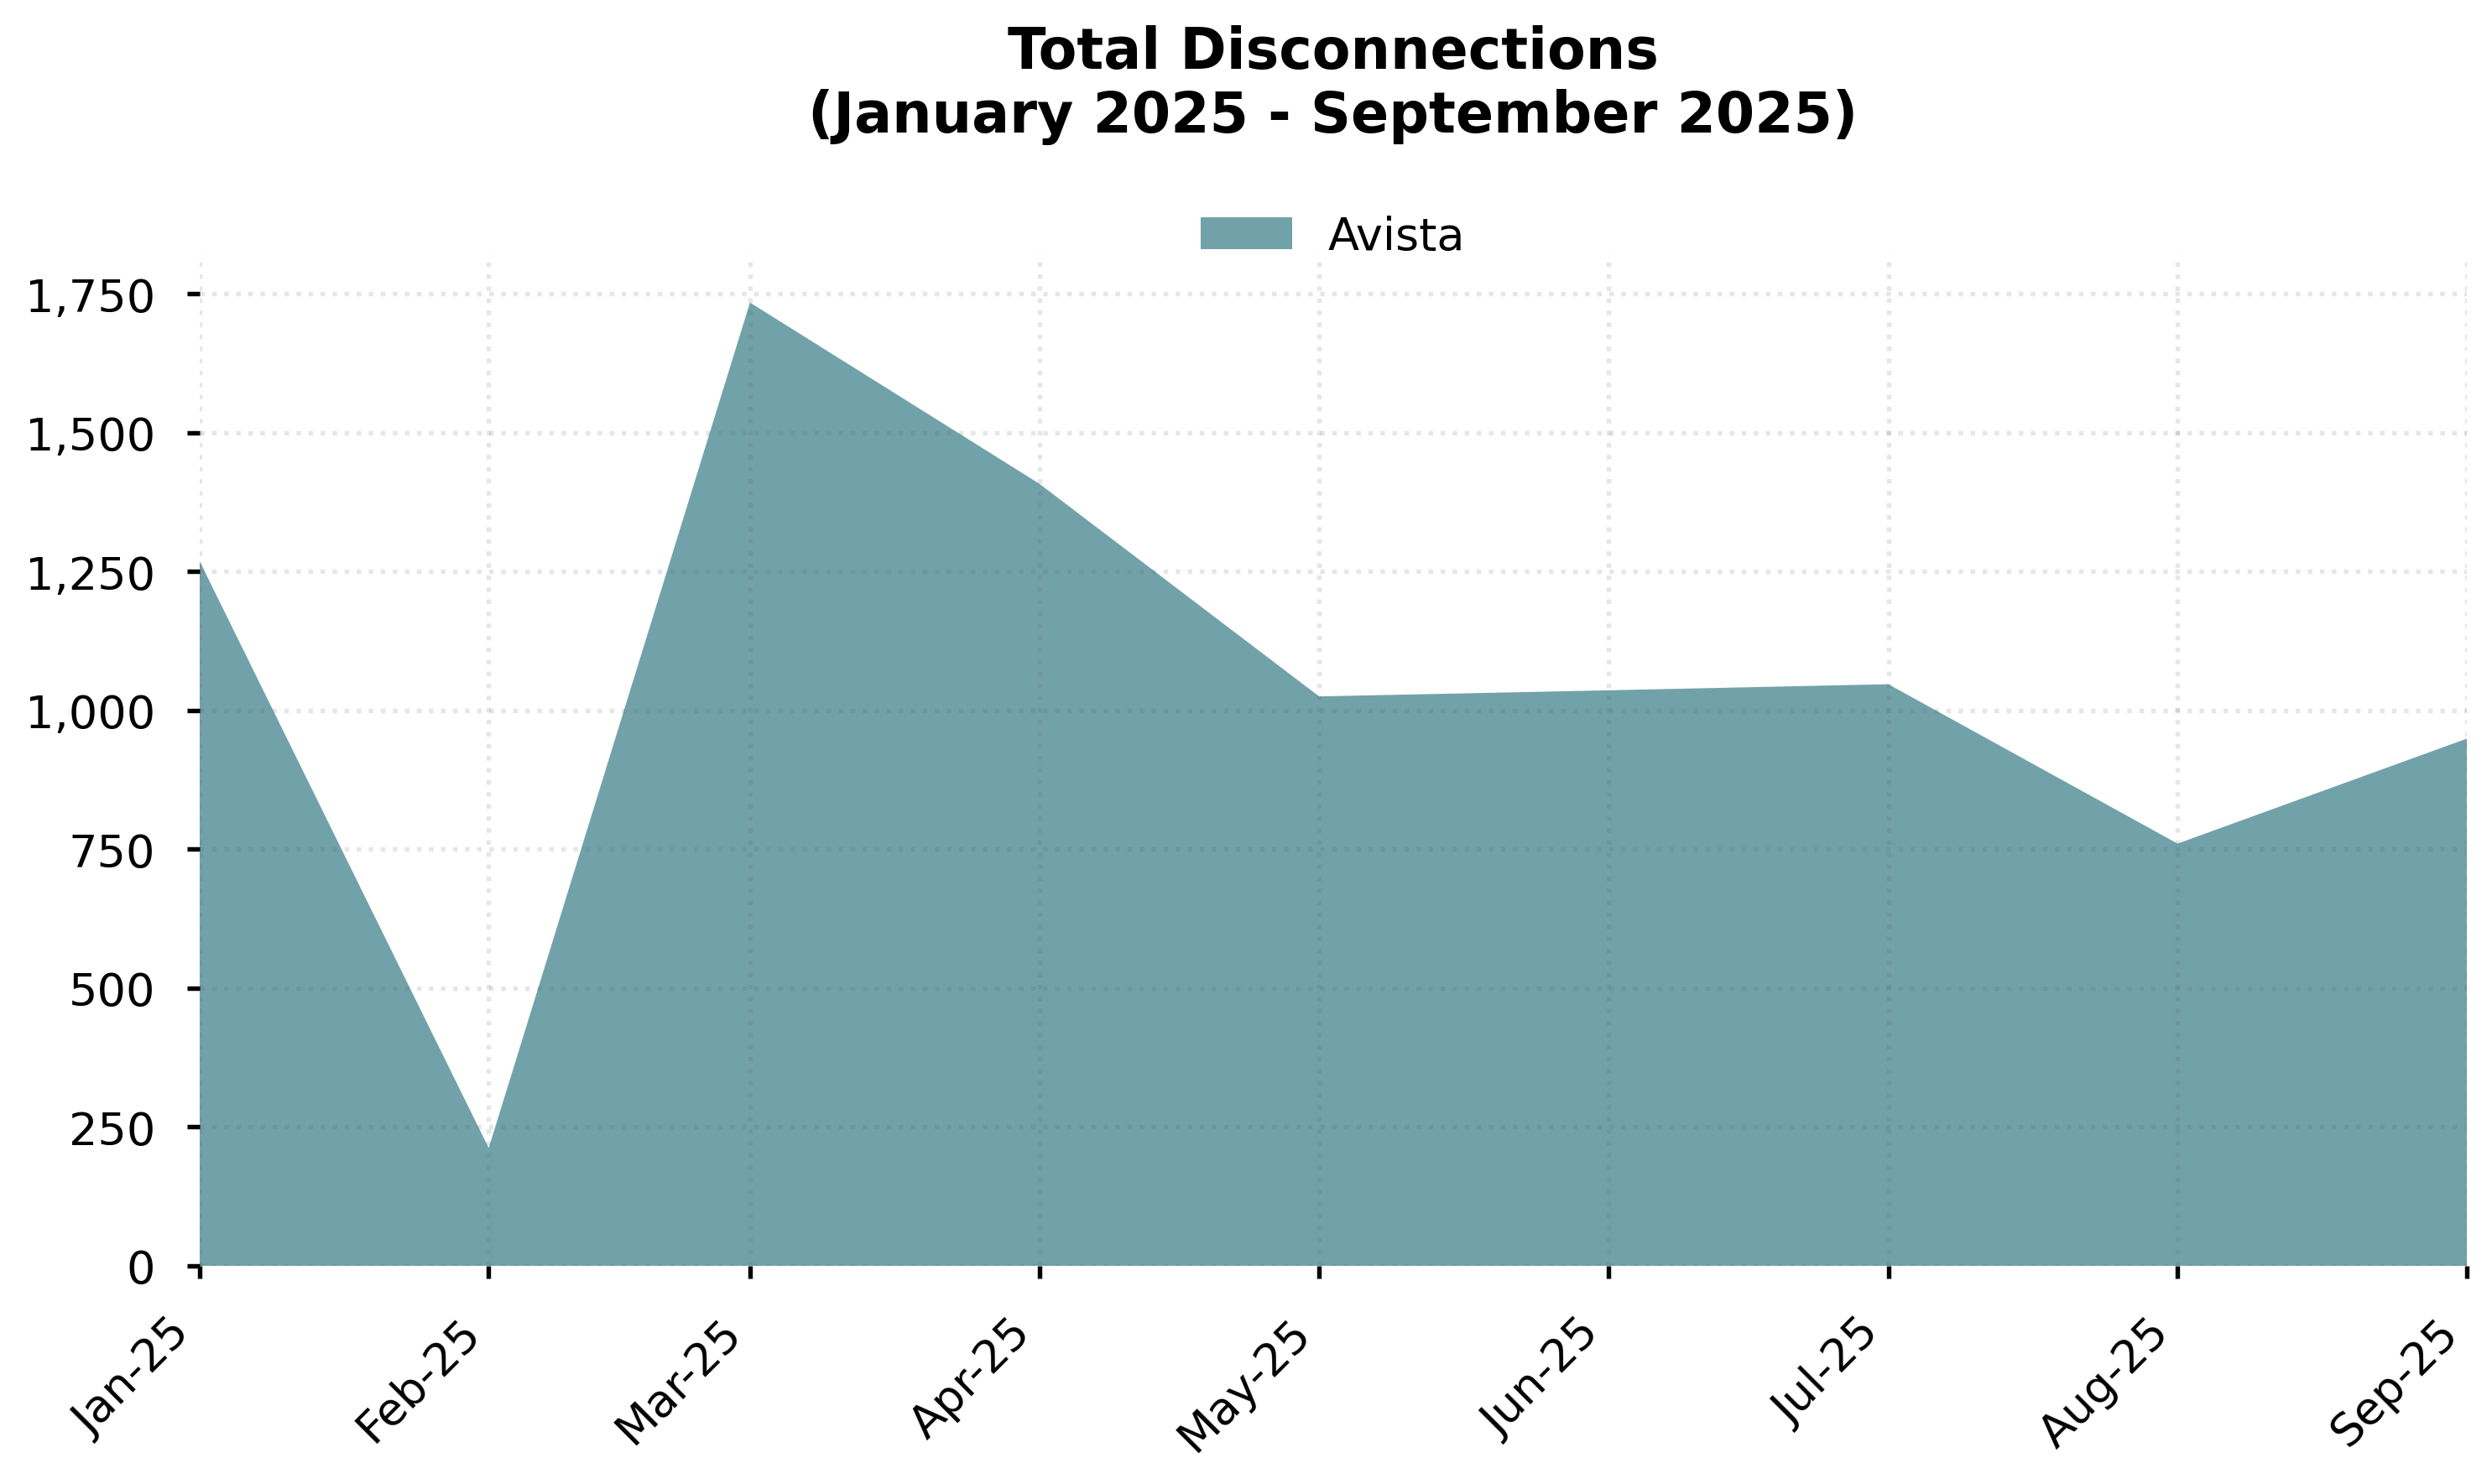

In [19]:
# Create stacked area chart for disconnections by utility
with plt.style.context("seaborn-v0_8-talk"):
    df_pandas_disconnections = df_disconnections_pivot.to_pandas()
    dates_disconnections = df_pandas_disconnections["Date"]

    # Get first and last month for title
    first_month_disconnections = dates_disconnections.min().strftime("%B %Y")
    last_month_disconnections = dates_disconnections.max().strftime("%B %Y")

    colors = ["#156570", "#B4CEB3", "#9B7EDE", "#FE5F55", "#5C415D"]

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    # Set up grid
    ax.grid(which="major", axis="x", linestyle=":", color="#5b5b5b", alpha=0.15, zorder=1)
    ax.grid(which="major", axis="y", linestyle=":", color="#5b5b5b", alpha=0.15, zorder=1)

    # Get utility columns in Utility enum order, but only include those present in the data
    all_utilities = [Utility[util.name].code for util in Utility]
    available_utilities = [util for util in all_utilities if util in df_pandas_disconnections.columns]
    # Prepare data for stackplot
    utility_data_disconnections = [df_pandas_disconnections[util].values for util in available_utilities]

    # Create stacked area chart
    ax.stackplot(
        dates_disconnections,
        *utility_data_disconnections,
        labels=available_utilities,
        alpha=0.6,
        colors=colors[: len(available_utilities)],
    )

    # Formatting
    ax.set_title(
        f"Total Disconnections\n({first_month_disconnections} - {last_month_disconnections})",
        fontsize=16,
        fontweight="bold",
        pad=35,
    )
    ax.set_xlabel("")  # Remove x-axis label
    ax.set_ylabel("")

    # Format x-axis dates as "Jan-25"
    ax.xaxis.set_major_formatter(DateFormatter("%b-%y"))
    plt.xticks(rotation=45, ha="right")  # Rotate labels

    # Format y-axis with thousands separator
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

    # Remove all spines except left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Remove padding on x-axis to eliminate space on left
    ax.margins(x=0)

    # Move legend to horizontal at top, below title with more spacing
    ax.legend(loc="upper center", frameon=False, ncol=len(available_utilities), bbox_to_anchor=(0.5, 1.08))

    plt.tight_layout()
    plt.savefig("graphs/disconnections_stacked.png", dpi=300, bbox_inches="tight")
    plt.show()